In [140]:
# to_save, to_load = False, True
session_file = "./tmp/TIC_337216607_EA.ipynb.pkl"

# # load/save the notebook session
# # https://dill.readthedocs.io/en/latest/
# if True: 
#     import dill
#     import sys
#     if "../" not in sys.path:  # to get my usual helpers at base dir
#         sys.path.append("../")
#     if "../eb_with_diff_sb_period/etv/" not in sys.path:  # for etvp
#         sys.path.append("../eb_with_diff_sb_period/etv/")
#     dill.load_module(session_file)
#     print(f"Notebook session loaded from  {session_file}")

# if True:  # save the notebook session
#     import dill
#     dill.dump_module(session_file)
#     print(f"Notebook session saved in {session_file}")


Notebook session saved in ./tmp/TIC_337216607_EA.ipynb.pkl


In [1]:
import sys
if "../" not in sys.path:  # to get my usual helpers at base dir
    sys.path.append("../")

import lightkurve as lk
from lightkurve_ext import of_sector, of_sectors, of_2min_cadences
import lightkurve_ext as lke
from lightkurve_ext import TransitTimeSpec, TransitTimeSpecList
import lightkurve_ext_tess as lket
import lightkurve_ext_pg as lke_pg
import lightkurve_ext_pg_runner as lke_pg_runner
import tic_plot as tplt

import asyncio_compat

import math
import re
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as matplotlib

import pandas as pd
import astropy as astropy
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time, TimeDelta
from astropy.io import fits

from matplotlib.ticker import (FormatStrFormatter, AutoMinorLocator)

from importlib import reload # useful during development to reload packages

from IPython.display import display, HTML, Javascript, clear_output

display(HTML("<style>.container { width:99% !important; }</style>"))  # Jupyter 6
display(HTML("<style>.jp-Notebook { --jp-notebook-max-width: 98%; }</style>"))  # Jupyter 7


# No longer works in Jupyter 7+
display(Javascript("""
// export notebook url to Python for bokeh-based interactive features
if (window["IPython"] != null) {
  IPython.notebook.kernel.execute(`notebook_url = "${window.location.origin}"`);
} else {
  console.warn("IPython js object not available (in Jupyter 7). Hardcode notebook_url in the notebook itself instead.")
}
"""));
notebook_url = "localhost:8888"

%matplotlib inline

# data cache config
lk_download_dir = '../data'
if hasattr(lk, "conf"):  # default download dir
    lk.conf.cache_dir = lk_download_dir

# make markdown table aligned to the left of the cell output (instead of center)
display(HTML("<style>table {margin-left: 4ch;}</style>"))

<IPython.core.display.Javascript object>

# TIC 337216607 Analysis (EA)

- new VSX entry


## TESS Data

In [28]:
tic = 337216607

sr = lk.search_lightcurve(f"TIC{tic}", )  # author="SPOC", cadence="short"
sr_unfiltered = sr  # keep a copy
sr = lke.filter_by_priority(sr, author_priority = ["SPOC", "TESS-SPOC", "QLP"])
# sr = sr[sr.author == "QLP"]  # for uniformity, only 1 sector (3) has no QLP data
# sr = lke._sort_chronologically(sr)

astropy.table.pprint.conf.max_lines = 100  # to print all rows
display(sr)

# Note: only 1 sector of ready made lightcurve
# if needed, lightcurves can be created from sectors 37, 63, 64 (and in the future 90, 99, 100, 101)
lcc_tess = sr.download_all()
lcc_tess

#,mission,year,author,exptime,target_name,distance,proposal_id
,,,,s,,arcsec,
0,TESS Sector 31,2020,SPOC,120,337216607,0.0,G03251
1,TESS Sector 42,2021,SPOC,120,337216607,0.0,G04103
2,TESS Sector 43,2021,SPOC,120,337216607,0.0,G04103
3,TESS Sector 70,2023,SPOC,120,337216607,0.0,N/A
4,TESS Sector 71,2023,SPOC,120,337216607,0.0,N/A


LightCurveCollection of 5 objects:
    0: <TessLightCurve LABEL="TIC 337216607" SECTOR=31 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 337216607" SECTOR=42 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 337216607" SECTOR=43 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 337216607" SECTOR=70 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 337216607" SECTOR=71 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>

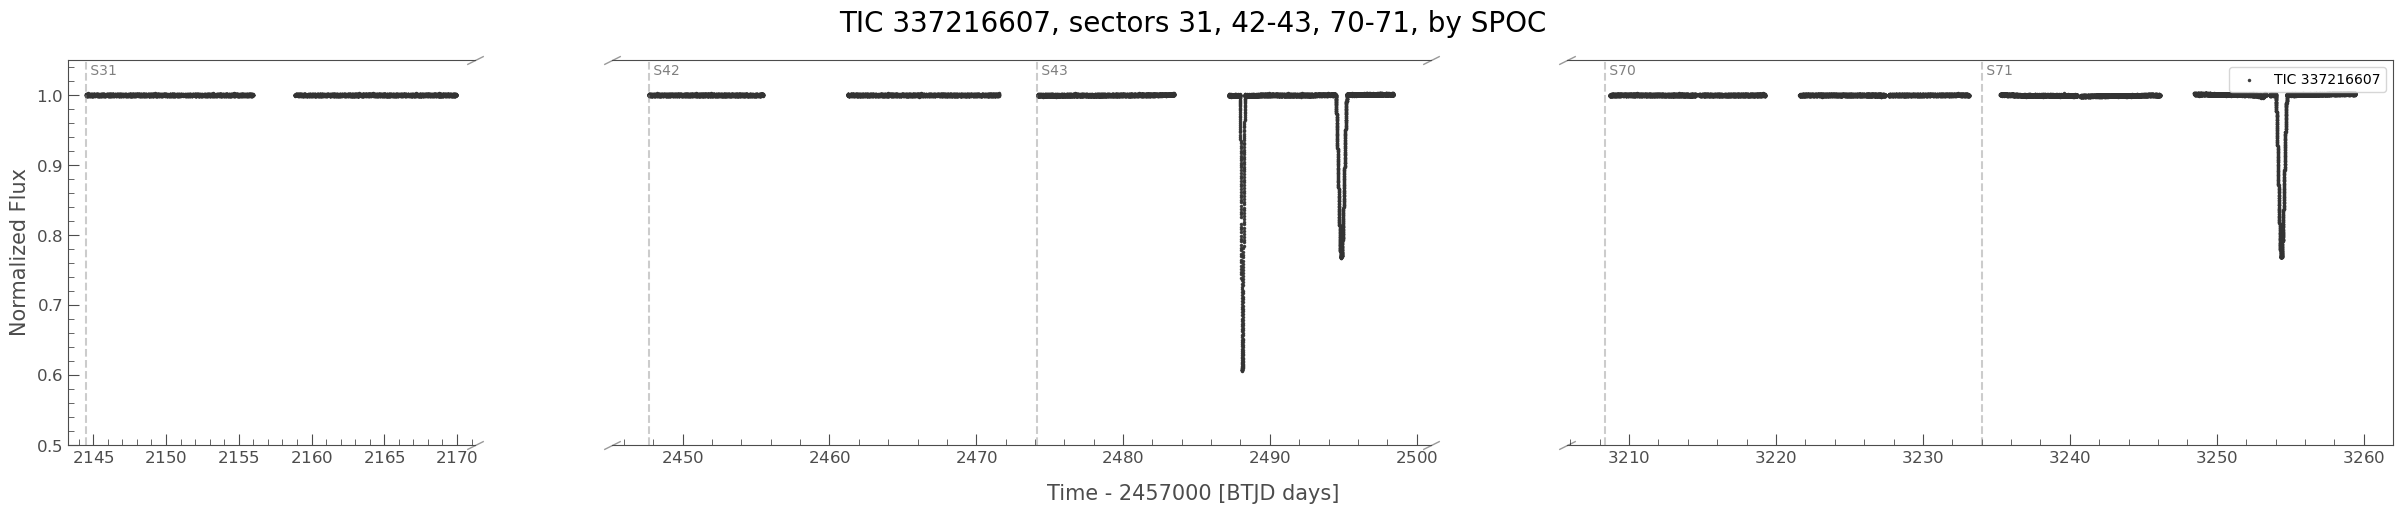

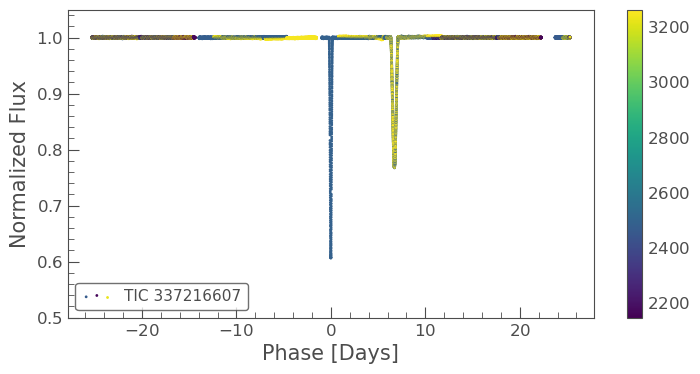

In [32]:
_lc = lke.stitch(lcc_tess, ignore_incompatible_column_warning=True)  # , corrector_func=lambda lc: lc.select_flux("sap_flux").normalize()

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}", fontsize=20);
[ax.set_ylim(0.5, 1.05) for ax in axs];

_lc_f = _lc.fold(period=50.635, epoch_time=Time(3247.66, format="btjd"), )  # wrap_phase= # rough initial epoch / period to gauge usefulness of the data
ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);
ax.set_ylim(0.5, 1.05);
# ax.set_xlim(5, 10); ax.set_ylim(0.95, None);  # zoomed around Min II

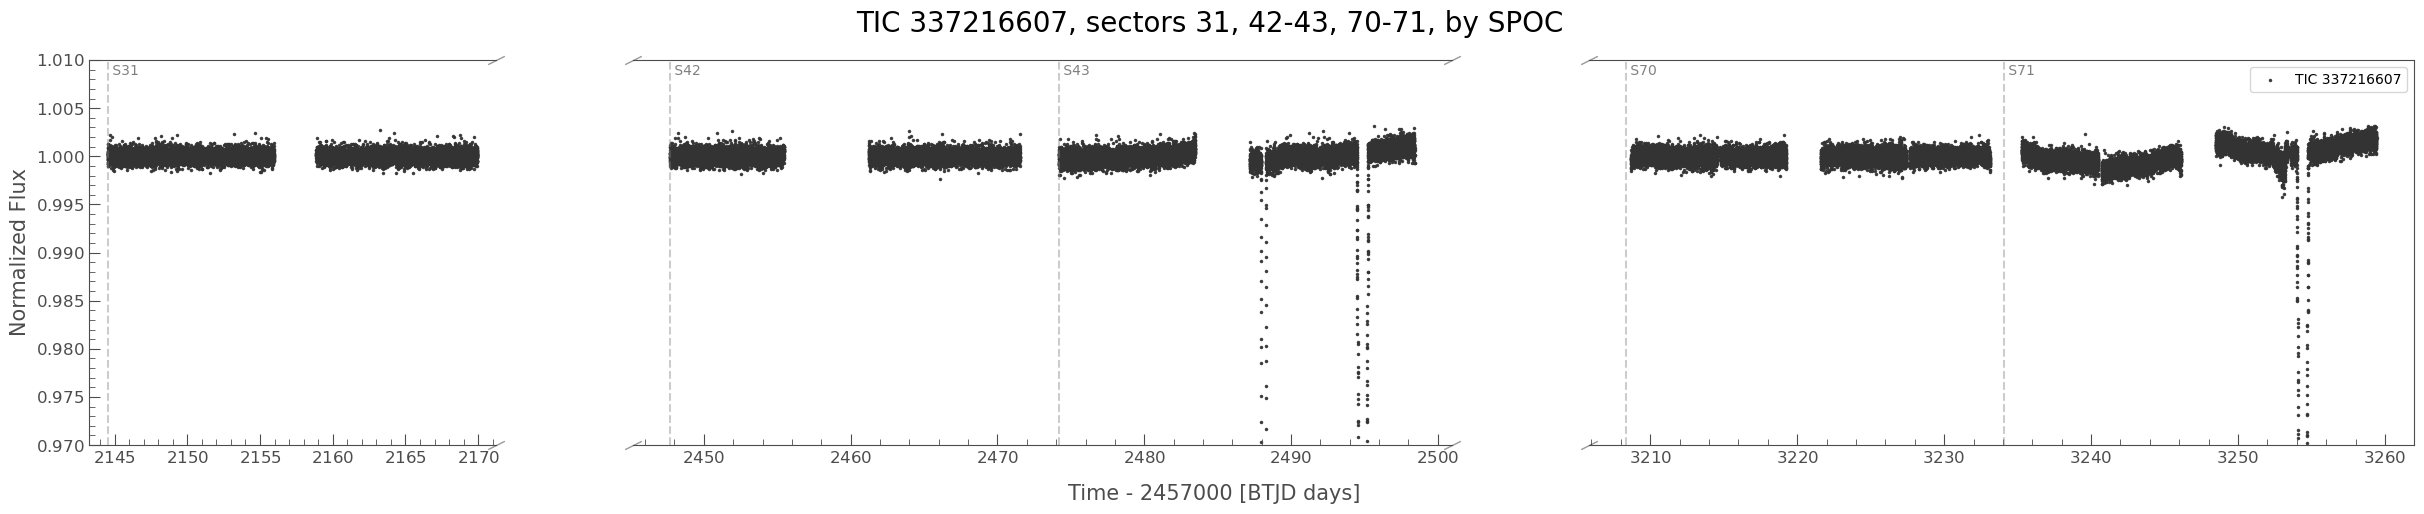

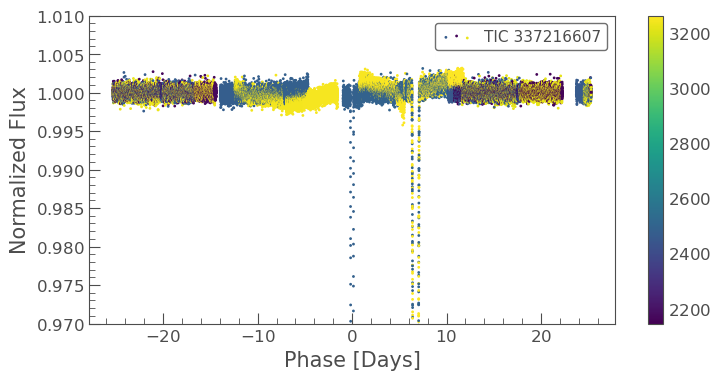

In [34]:
# truncating the eclipses to see out of eclipse variation

_ylim = (0.97, 1.01)
axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author} ", fontsize=20);
[ax.set_ylim(*_ylim) for ax in axs];

ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);
ax.set_ylim(*_ylim);

### Use SPOC over QLP data

- SPOC data has less systematics
- QLP data has 1 additional deep eclipse, but it's in an area with lots of systematics

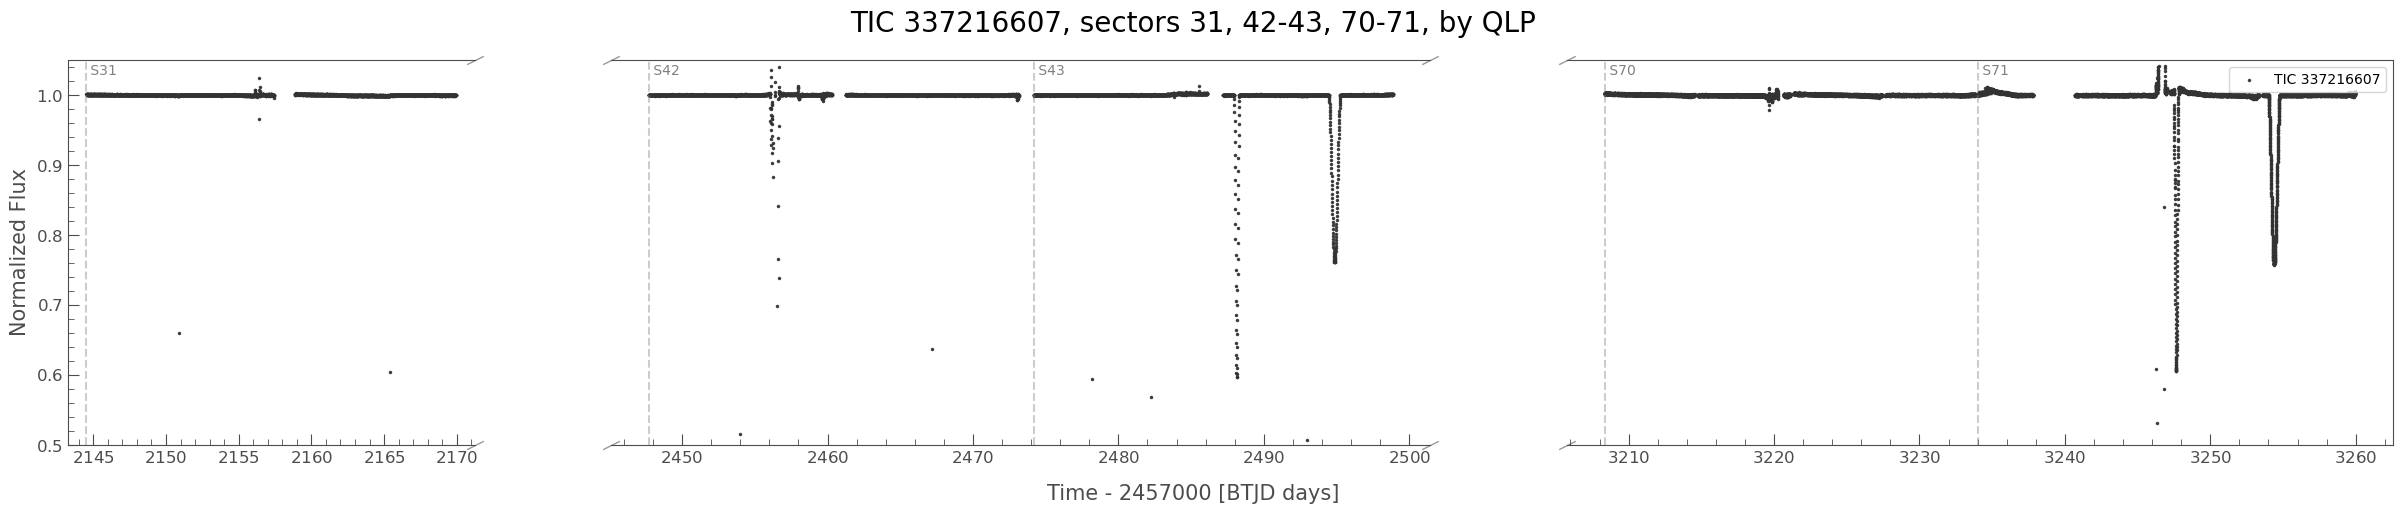


Eclipses truncated: 

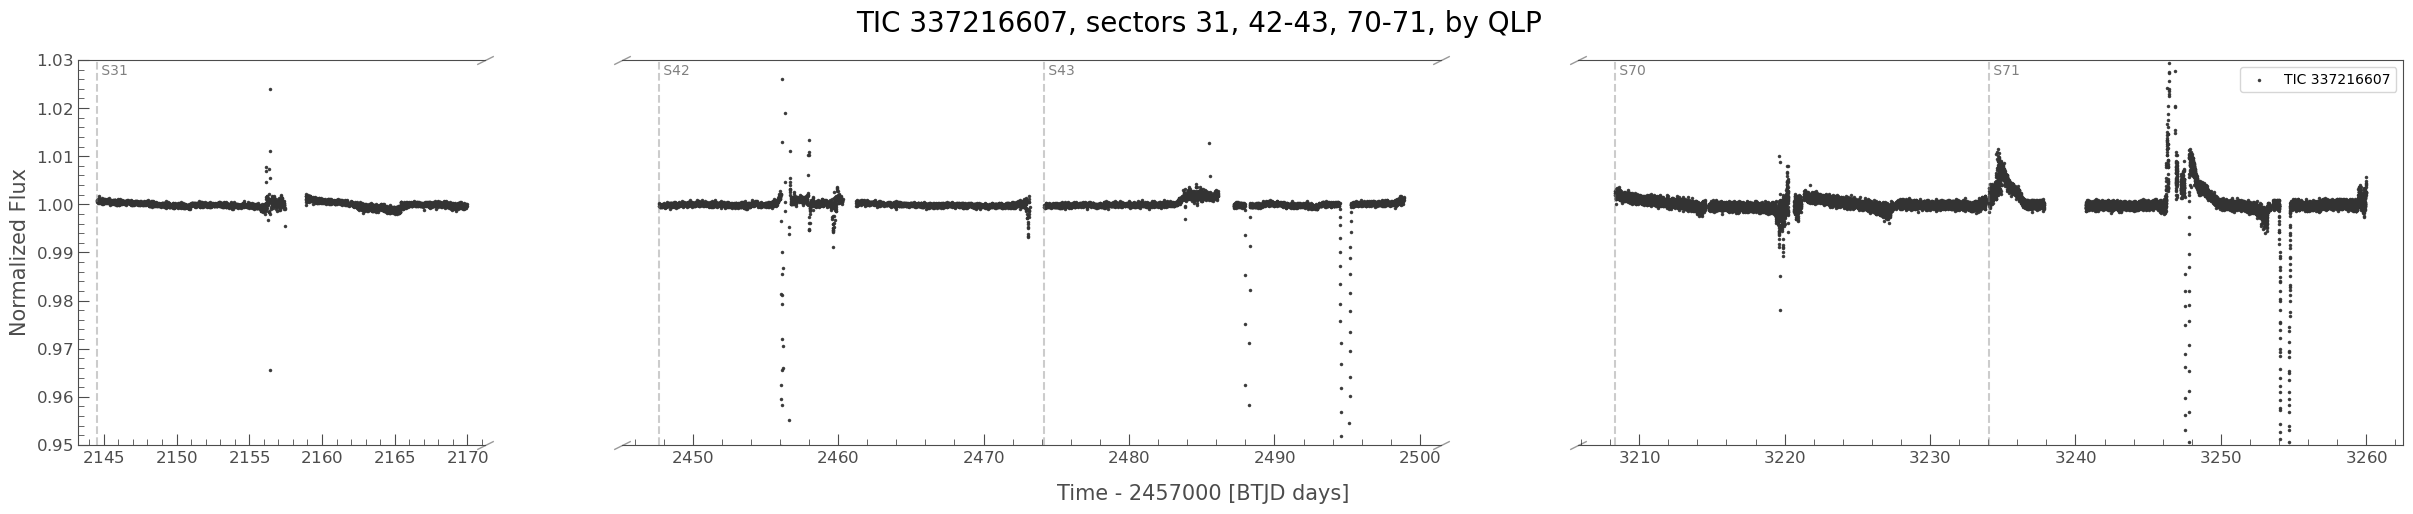


## Gaia DR3 info (coordinate, etc.)

In [11]:
# reload(lke)
# reload (lket)
rs_all_cols, rs, rs_html  = lket.search_gaiadr3_of_tics(tic, radius_arcsec=15, magnitude_range=None,  pm_error_factor=None, pm_range_fraction=None, pm_range_minimum=None, 
                                                        calc_separation_from_first_row=True,  # assuming the first row is the target, it'd calculate more accurately the separation for Gaia DR3 Main
                                                        compact_columns=True, also_return_html=True, also_return_astrophysical=False, verbose_html=True, include_nss_summary_in_html=False)
display(HTML(rs_html))

# from Gaia DR3
target_coord = SkyCoord(rs[0]["RAJ2000"], rs[0]["DEJ2000"], unit=(u.deg, u.deg), frame="icrs")
target_coord_dict = dict(ra=target_coord.ra.value, dec=target_coord.dec.value)


In [87]:
primary_name = "HD 15815" # use HD name rather than TIC given it's a bright star # f"TIC {tic}"
primary_name

'HD 15815'

## Combining all data

- ASAS-SN SkyPatrol : data does not have the photometric precision
- NSVS: it has data but I don't know how to acccess it. See [Vizier](https://vizier.cds.unistra.fr/viz-bin/VizieR-4?-source=+II%2F287%2Fskydot&-from=nav&-nav=cat%3AII%2F287%26tab%3A%7BII%2F287%2Fskydot%7D%26key%3Asource%3DII%2F287%26key%3Ac%3DHD+15815%26pos%3AHD+15815%28%29%26HTTPPRM%3A%26%26-ref%3DVIZ69e0242e2f69f8%26-out.max%3D50%26-out.form%3DHTML+Table%26-out.add%3D_r%26-sort%3D_r%26-order%3DI%26-oc.form%3Dsexa%26-c%3DHD+15815%26-c.eq%3DJ2000%26-c.r%3D++5%26-c.u%3Darcsec%26-c.geom%3Dr%26-out%3DRAJ2000%26-out%3De_RAJ2000%26-out%3DDEJ2000%26-out%3De_DEJ2000%26-out%3Dmag%26-out%3De_mag%26-out%3Demag%26-out%3DNobs%26-out%3DN1%26-out%3DNdet%26-out%3Dflag%26-out%3DField%26-out%3DGLON%26-out%3DGLAT%26-out%3DNfr%26-out%3DNobj%26-out%3Dsig-ph%26-out%3DID%26-out%3DCam%26-out%3DJD%26-out%3DTime%26-out%3DDate%26-out%3DExpTime%26-out%3Dbkg%26-out%3De_bkg%26-out%3De_pos%26-out%3Dzpoffset%26-out%3De_zpoffset%26-out%3Dmlim%26-out%3Dmsat%26-out%3DNobj2%26-out%3DNmatch%26-out%3DObj1%26-out%3DObj2%26-out%3DSep%26-out.src%3DII%2F287%2Fskydot%2CII%2F287%2Ffields%2CII%2F287%2Fframes%2CII%2F287%2Fsynonym%26-meta.ucd%3D2%26-meta%3D1%26-meta.foot%3D1%26-usenav%3D5%26-bmark%3DPOST%26) .
- In Tycho-2 but not in HIP (i.e., no LC data)



### TESS: onvert to mag and HJD


In [ ]:
# helper to review the data interactively
tplt.plot_transit_interactive(_lc, figsize=(30, 8), plot_kwargs=dict(normalize=False, plot_kwargs=dict(s=25),));

In [35]:
_lc = lke.stitch(lcc_tess, ignore_incompatible_column_warning=True,)  # corrector_func=lambda lc: lc.select_flux("sap_flux").normalize()

# no need for additional filter 

# convert to mag and HJD
lc_tess = _lc
lc_tess = lke.to_flux_in_mag_by_normalization(lc_tess)
lc_tess = lke.convert_lc_time_to_hjd_utc(lc_tess, target_coord=target_coord, cache_dir=lk_download_dir)
len(lc_tess)

84528

### ASAS-3

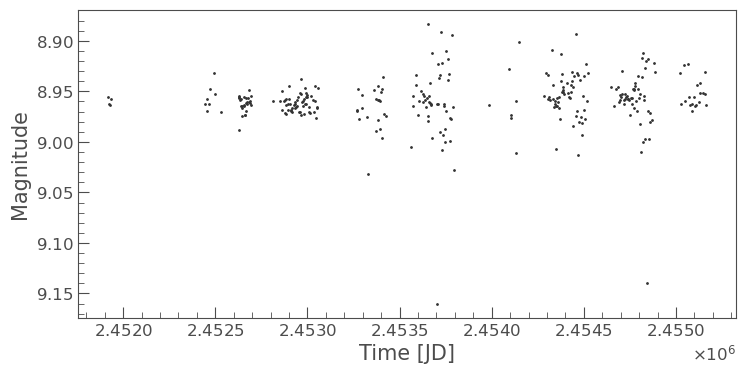

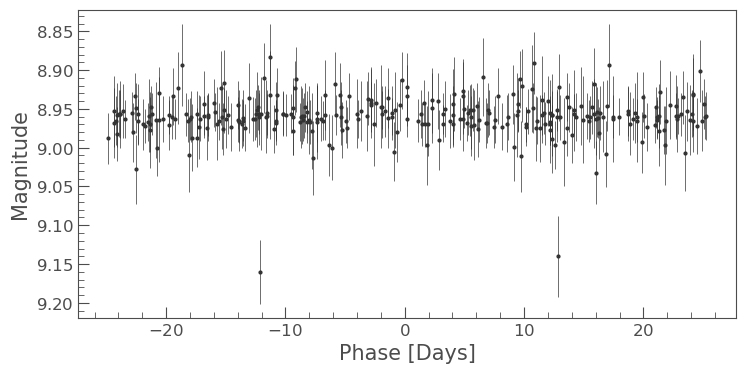

In [38]:
import lightkurve_ext_readers as lker

_lc = lker.read_asas3("http://www.astrouw.edu.pl/cgi-asas/asas_cgi_get_data?023246+0725.6,asas3")
ax = tplt.scatter(_lc)

_lc_f = _lc.fold(period=50.635, epoch_time=Time(3247.66, format="btjd"), )  # wrap_phase= # rough initial epoch / period to gauge usefulness of the data
ax = tplt.errorbar(_lc_f);

lc_asas3 = _lc

### Do Actual combining

TESS # data points: 84528
ASAS-3 # data points: 317


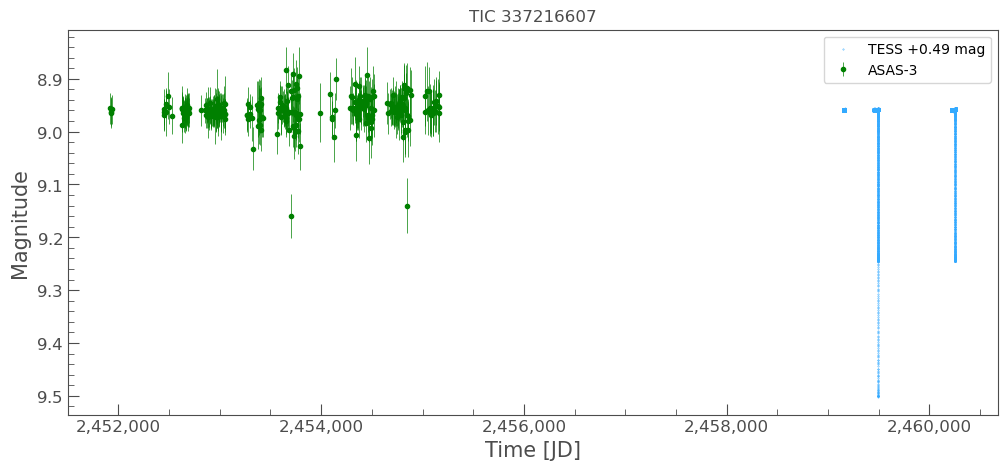

In [41]:
# Convert the data to magnitude and HJD/UTC

import lightkurve_ext_multi_sources as lkem
# reload(lkem)

lc_combined_dict = lkem.combine_multi_bands_and_shift(
    {"TESS": lc_tess, 
     "ASAS-3": lc_asas3,
    }, 
    shift_to="ASAS-3",
)

for k in lc_combined_dict.keys():
    print(f"{k} # data points:", len(lc_combined_dict[k]))

plot_options = lkem.get_default_plot_multi_bands_options_copy()
# for TESS plot (index 0) move it to the front
# plot_options[0][1]["zorder"] = 3  # default 2

ax = lkem.plot_multi_bands(lc_combined_dict, figsize=(12, 5), target_name=primary_name, plot_options=plot_options);
# ax.set_ylim(15.2, 14.0);

## Initial epoch / period / duration


In [ ]:
# possible periods from TESS data
[759.525,
 379.76250000000005,
 253.17500000000004,
 189.88125000000002,
 151.90500000000003,
 126.58750000000002,
 94.94062500000001,
 75.95250000000001,
 63.29375000000001,
 58.425000000000004,
 50.635000000000005]

Adopted period / epoch / duration_hr:  94.941 2459488.13 8 18.5


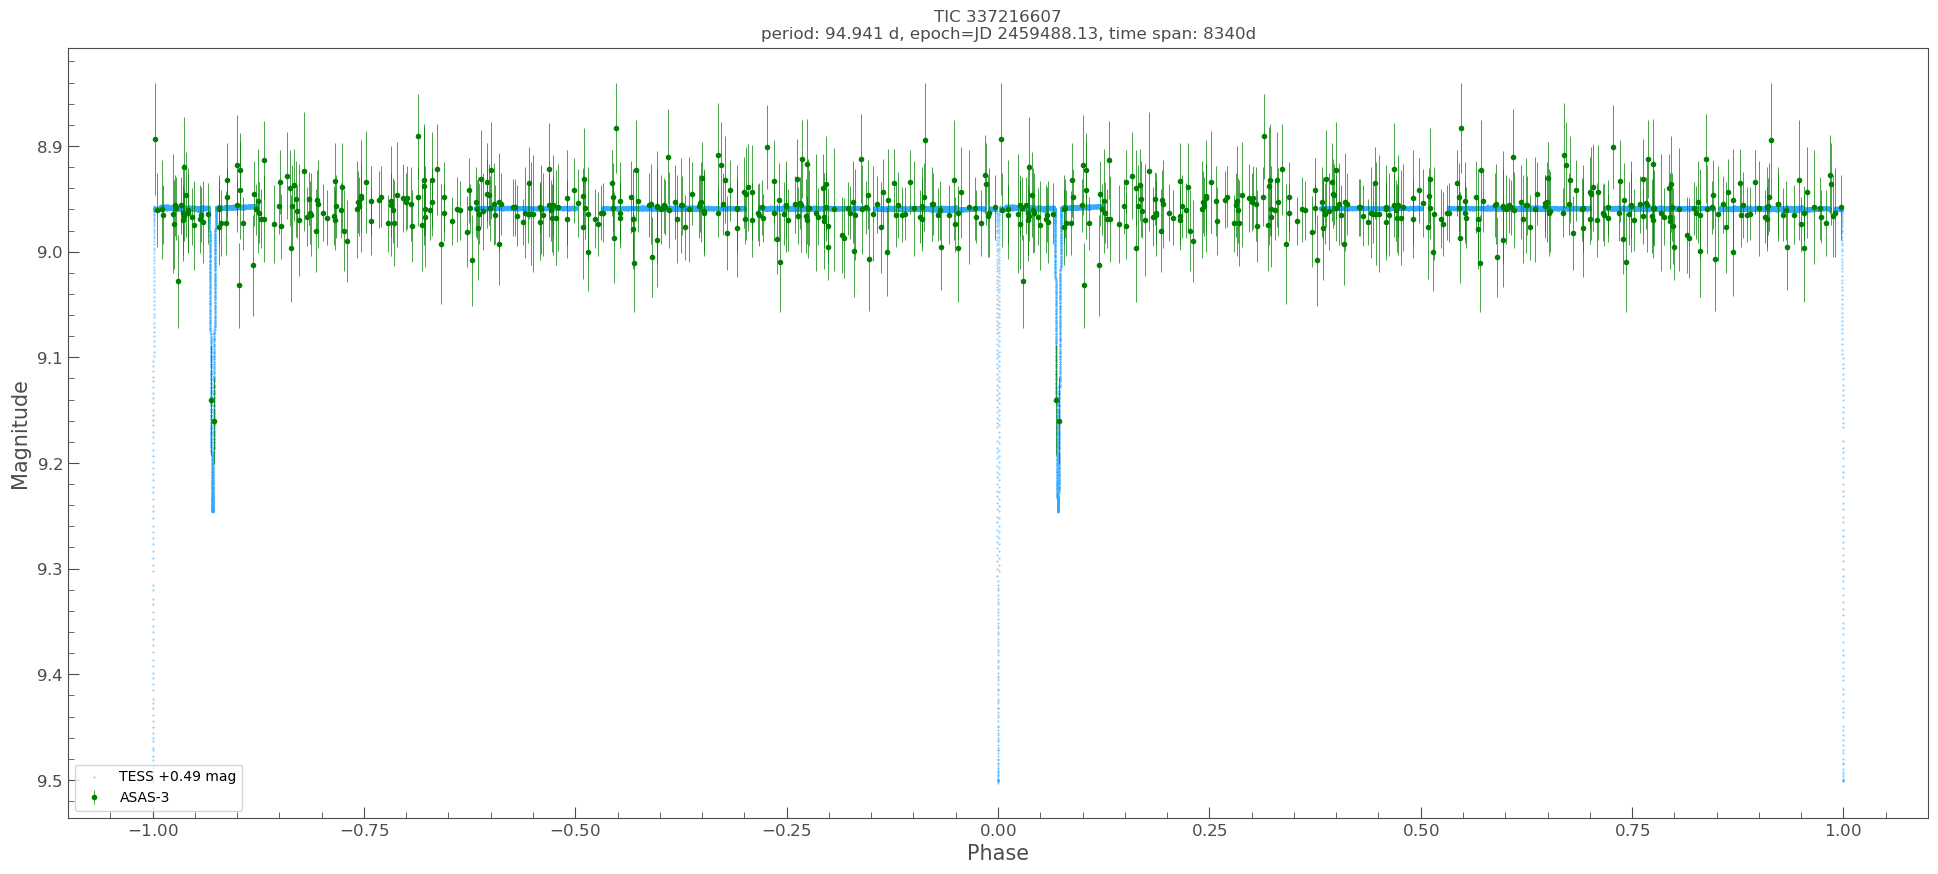

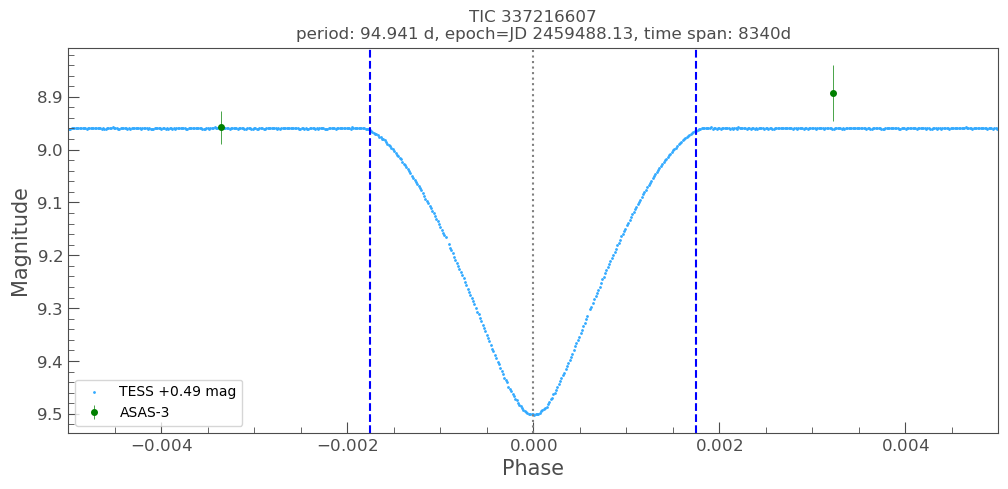

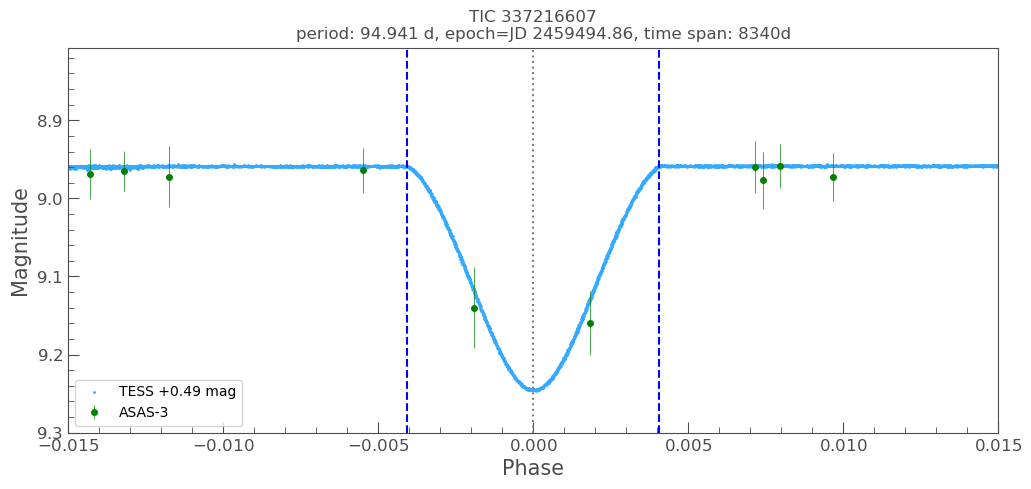

In [67]:
# reload(lkem)

# epoch / period / duration from manual inspection

period_trial = 94.941  # if the 2 dots in ASAS-3 are eclipses, the period is 94.941 , otherwise, the  period is 50.635 - 759.525
epoch_time_btjd_trial = 2488.13
epoch_time_hjd_trial = round(lket.btjd_to_hjd_utc(epoch_time_btjd_trial, target_coord), 2)  # need 3 digit to ensure it does look off visually

# from visual inspection
epoch_time_min_ii_btjd_trial = 2494.865
epoch_time_min_ii_hjd_trial = round(lket.btjd_to_hjd_utc(epoch_time_min_ii_btjd_trial, target_coord), 2)  # need 3 digit to ensure it does look off visually
duration_hr_min_i_trial = 8
duration_hr_min_ii_trial = 18.5


print("Adopted period / epoch / duration_hr: ", period_trial, epoch_time_hjd_trial, duration_hr_min_i_trial, duration_hr_min_ii_trial)

# --- Plot them to verify ---

plot_options = lkem.get_default_plot_multi_bands_options_copy()

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_hjd_trial   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)
ax.set_ylim(*ylim);

# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1]["s"] = 1
# plot_options_zoom[0][1]["zorder"] = 3  # move to the front, default 2
plot_options_zoom[1][1].update(dict(marker='o', markersize=4))


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_hjd_trial, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_trial  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.005, 0.005);  # to see primary in details
ax.set_ylim(*ylim);


# zoom plot Min II
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_min_ii_hjd_trial, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_ii_trial  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.015, 0.015);  # to see primary in details
ax.set_ylim(9.3, None);


## Final period / epoch / duration

Adopted period / epoch / duration_hr:  94.941 2459488.13 0.0709 8 18.5


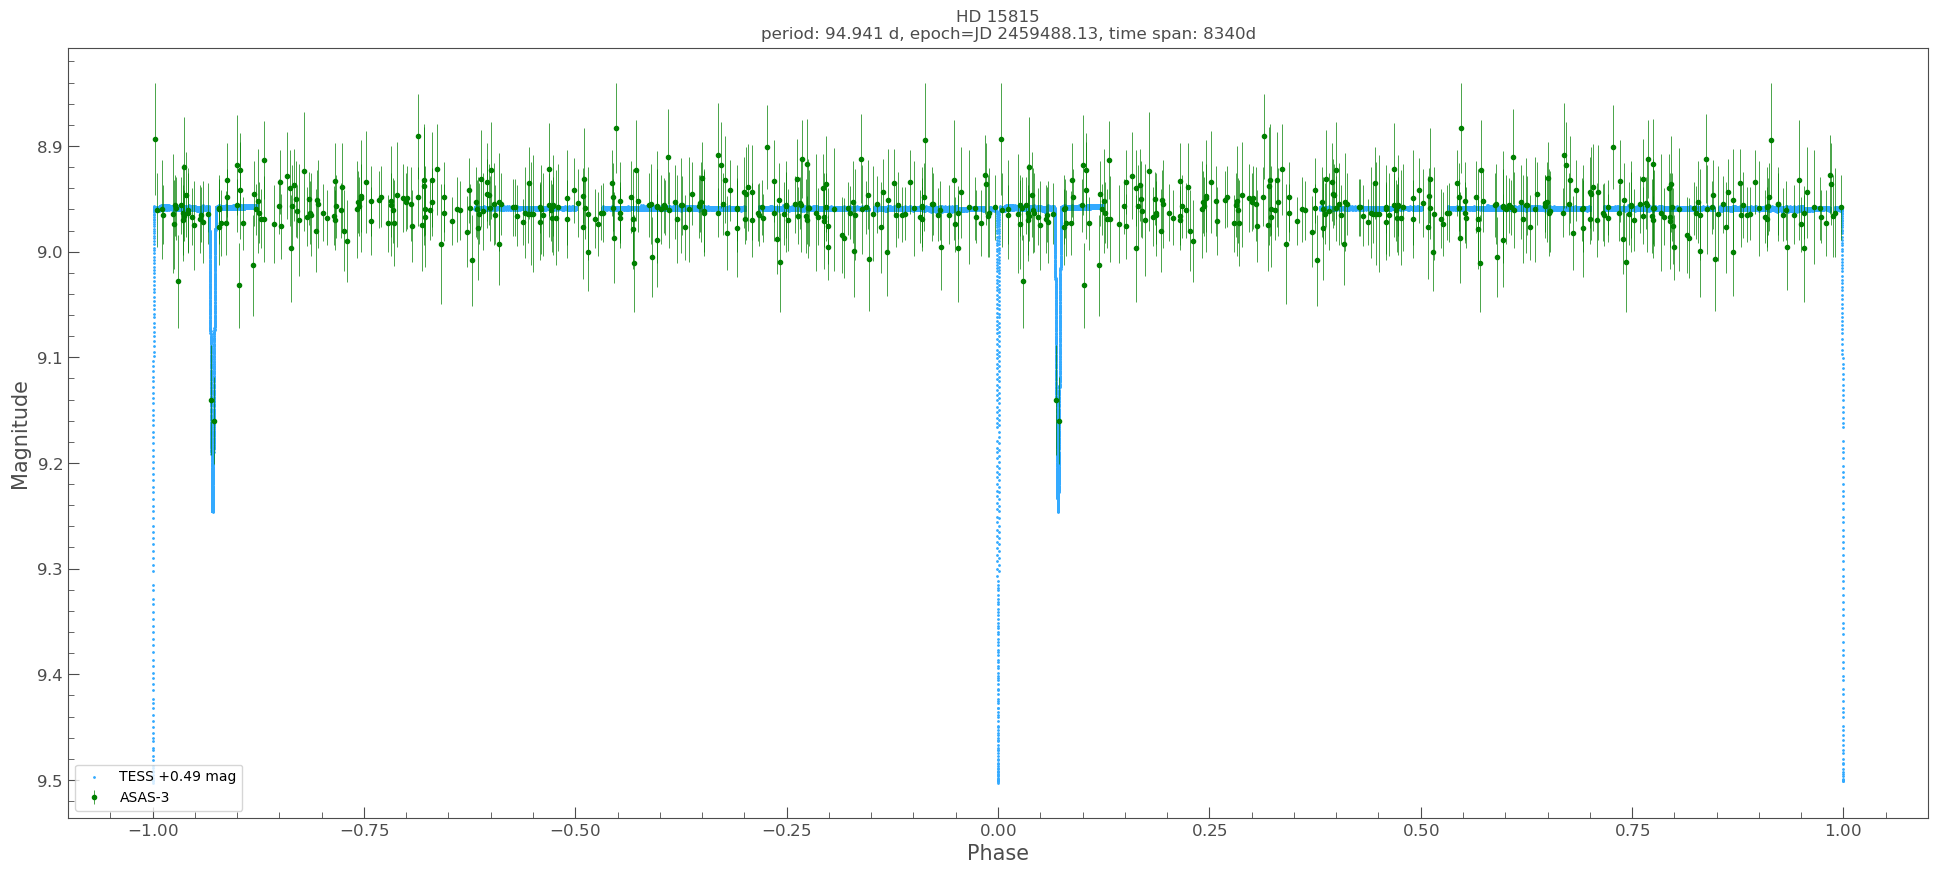

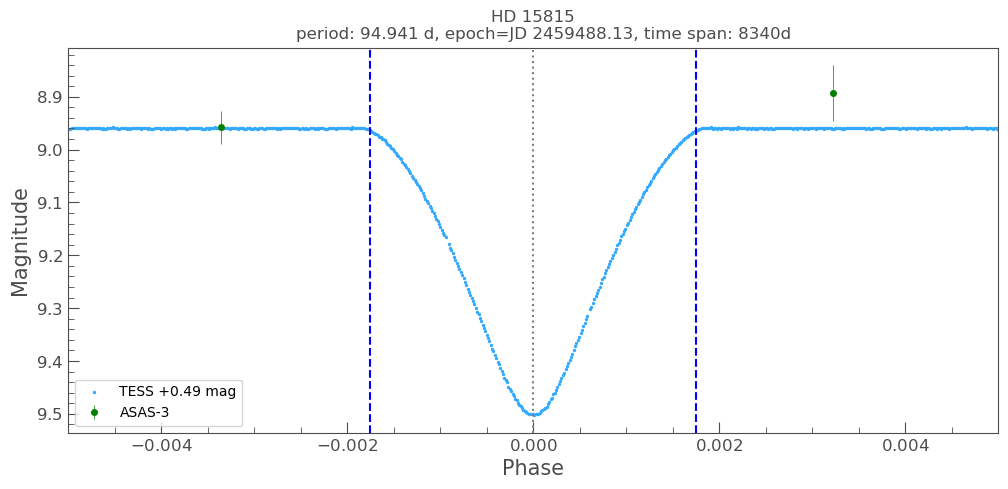

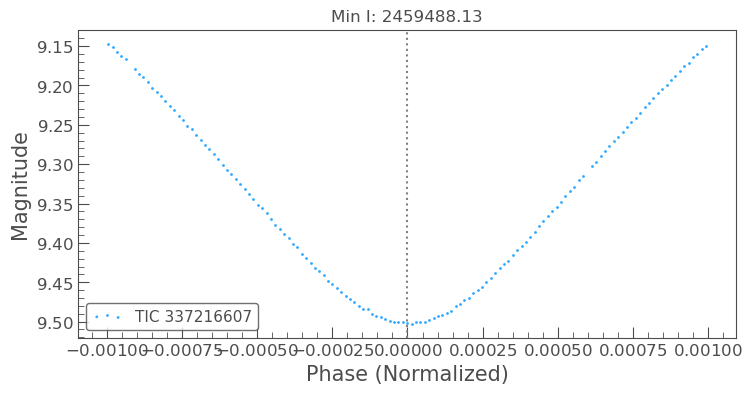

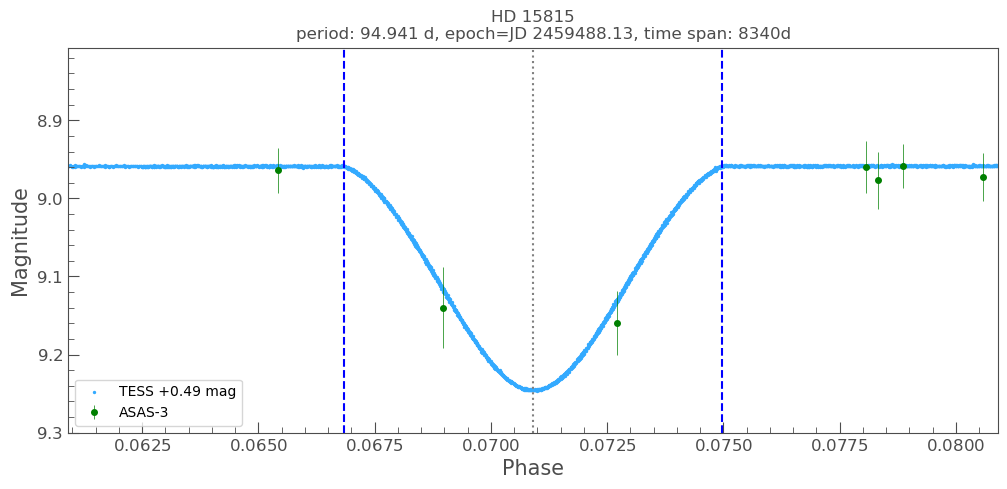

In [101]:
# reload(lkem)
from decimal import Decimal

period_final = period_trial
epoch_time_hjd_final = epoch_time_hjd_trial
duration_hr_min_i_final = duration_hr_min_i_trial 

epoch_time_min_ii_hjd_final = epoch_time_min_ii_hjd_trial

epoch_phase_min_ii_final   = abs(epoch_time_min_ii_hjd_final - float(epoch_time_hjd_final)  ) / period_final  % 1
epoch_phase_min_ii_final  = round(epoch_phase_min_ii_final, 4)  # precsion from eyeballing zoomed plot

duration_hr_min_ii_final = duration_hr_min_ii_trial


print("Adopted period / epoch / duration_hr: ", period_final, epoch_time_hjd_final, epoch_phase_min_ii_final, duration_hr_min_i_final, duration_hr_min_ii_final)

# --- plot to verify ---

plot_options = lkem.get_default_plot_multi_bands_options_copy()
plot_options[0][1]["s"] = 1

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)
ax.set_ylim(*ylim);

# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1]["s"] = 2
plot_options_zoom[1][1].update(dict(marker='o', markersize=4))


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_final  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.005, 0.005);  # to see primary in details
ax.set_ylim(*ylim);

ax = tplt.scatter(lc_f_res["TESS"].truncate(-0.001, 0.001), c="#3AF");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_title(f"Min I: {epoch_time_hjd_final}");

# zoom plot Min II
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_ii_final  ,  # for plotting only
    duration_midpoint_phase=epoch_phase_min_ii_final,
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(epoch_phase_min_ii_final, c="gray", linestyle="dotted");
ax.set_xlim(epoch_phase_min_ii_final - 0.01, epoch_phase_min_ii_final + 0.01);  # to see secondary in details
ax.set_ylim(9.3, None);


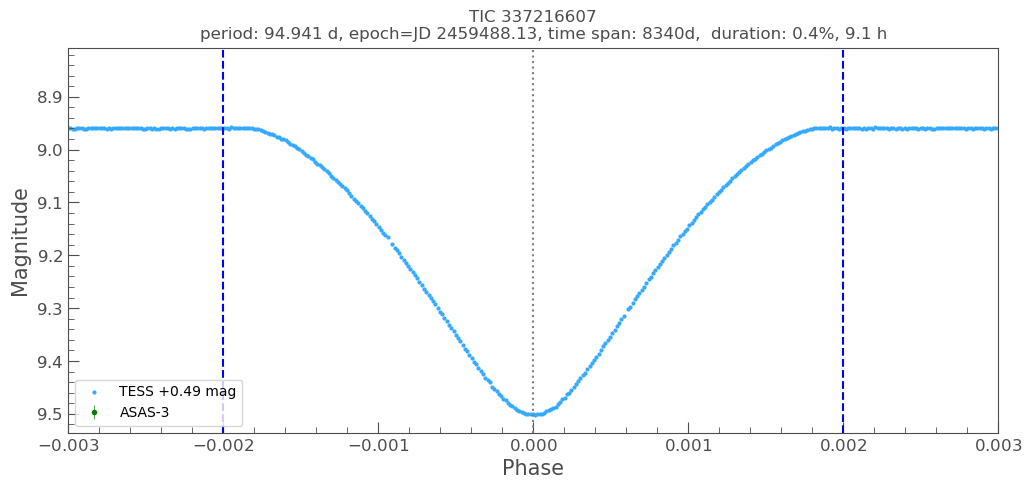

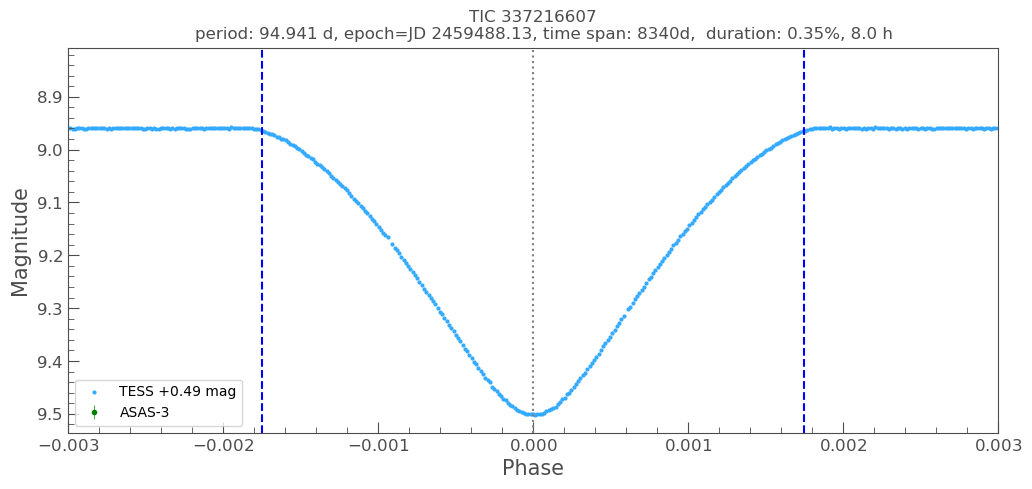

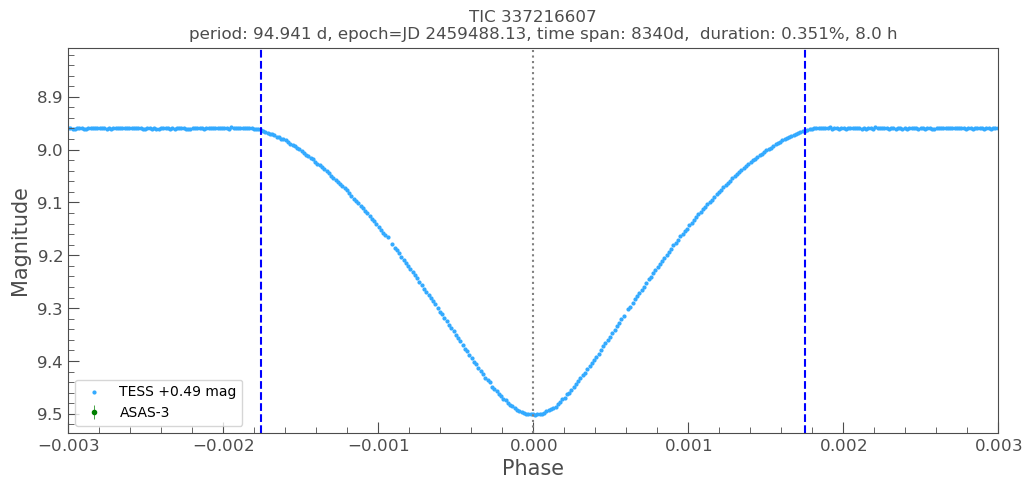

In [78]:
# demonstrate the precision difference in duration percentage 
# - 2 digits for percetnarge would be appropriate
for _precision in [1, 2, 3]: 
    _dur_pct = round(100 * duration_hr_min_i_final / 24 / period_final, _precision)
    _dur_hr = _dur_pct /100 * 24 * period_final
    # zoom plot Min I
    # - make TESS more visible:  larger dots
    plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
    plot_options_zoom[0][1]["s"] = 4
    ax, lc_f_res = lkem.fold_n_plot_multi_bands(
        lc_combined_dict,
        period=period_final,
        epoch=Time(epoch_time_hjd_final  , format="jd", scale="utc"),
        phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
        target_name=primary_name,
        duration_hr=_dur_hr,  # for plotting only
        figsize=(12, 5),
        plot_options=plot_options_zoom,
        # mag_shift_precision=2,  #
    );
    ax.set_ylim(*ylim);
    ax.legend(loc="lower left");
    ax.axvline(0, c="gray", linestyle="dotted");
    ax.set_xlim(-0.003, 0.003);  # to see primary in details
    ax.set_title(ax.get_title() + f",  duration: {_dur_pct}%, {_dur_hr:.1f} h");
    # print(_dur_pct, _dur_hr, duration_hr_min_i_final) 

## Determine Amplitude (TESS)


Min I mag # num data points: 16
Min II mag # num data points: 8
['8.9590', '9.5008']


(0.54, 0.29)

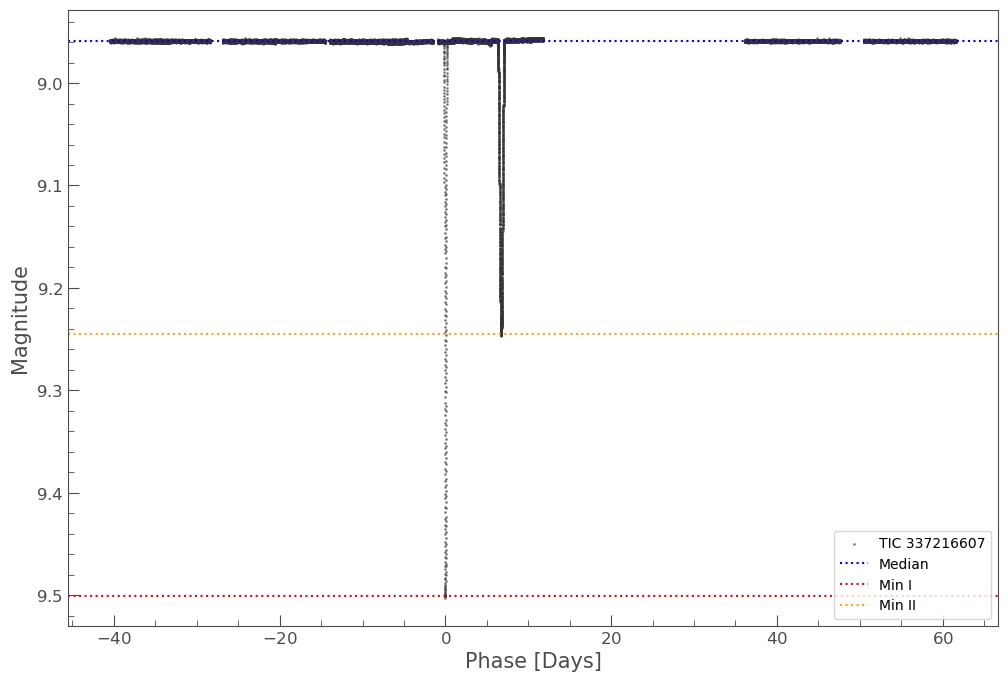

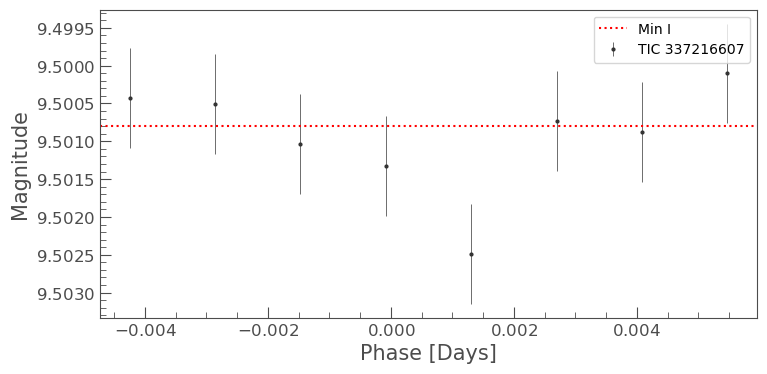

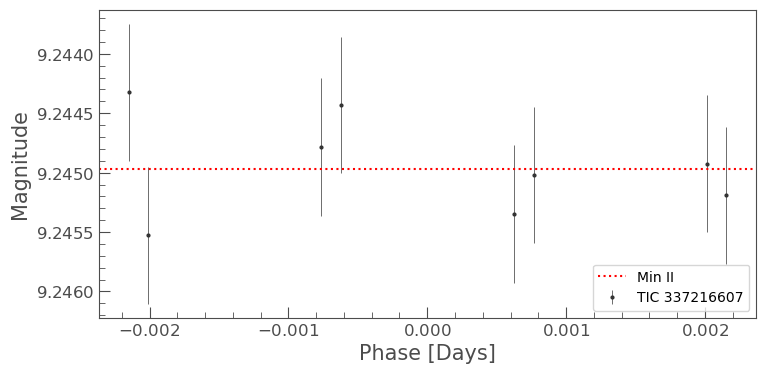

In [81]:
# %matplotlib widget
%matplotlib inline

# From TESS data
lc = lc_combined_dict["TESS"]

# max_flux_mag = lc.flux.min().value  #
# min_flux_mag = lc.flux.max().value
median_flux_mag = np.nanmedian(lc.flux.value)

# no max neded, medain is basically max
# lc_zoom_max = lc.fold(epoch_time=epoch_time_hjd_final + 0.75, period=period_final).truncate(0 - 1 /24/60, 0 + 1 /24/ 60)  
# print("Max mag # num data points:", len(lc_zoom_max))
# max_flux_mag = np.nanmedian(lc_zoom_max.flux.value)

lc_zoom_min = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final).truncate(0 - 8 /24/60, 0 + 8 /24/ 60)
print("Min I mag # num data points:", len(lc_zoom_min))
min_flux_mag = np.nanmedian(lc_zoom_min.flux.value)

lc_zoom_min_ii = lc.fold(epoch_time=epoch_time_min_ii_hjd_final, period=period_final).truncate(0 - 4 /24/60, 0 + 4 /24/ 60)
print("Min II mag # num data points:", len(lc_zoom_min_ii))
min_ii_flux_mag = np.nanmedian(lc_zoom_min_ii.flux.value)


lc_f = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final * 2)  # 2x period plot
ax = tplt.lk_ax(figsize=(12, 8))
ax = tplt.scatter(lc_f, ax=ax, alpha=0.5);
# ax.axhline(max_flux_mag, c="purple", linestyle="--", label="Max")
ax.axhline(median_flux_mag, c="blue", linestyle="dotted", label="Median")
ax.axhline(min_flux_mag, c="red", linestyle="dotted", label="Min I")
ax.axhline(min_ii_flux_mag, c="orange", linestyle="dotted", label="Min II")
ax.legend(loc="lower right");
# ax.set_xlim(-0.5, 0.5); 
ax.set_ylim(*ylim);


ax = tplt.errorbar(lc_zoom_min, marker="o");
ax.axhline(min_flux_mag, c="red", linestyle="dotted", label="Min I")
# ax.set_ylim(*ylim);
ax.legend();

ax = tplt.errorbar(lc_zoom_min_ii, marker="o");
ax.axhline(min_ii_flux_mag, c="red", linestyle="dotted", label="Min II")
ax.legend(loc="lower right");

print([f"{v:.4f}" for v in [median_flux_mag, min_flux_mag]])  # , min_ii_flux_mag


# # TESS only data, to report mean V mag and ampitude in TESS
# mean_flux_v_mag = np.round(rs_all_cols["Vmag"][0], 2)  # V converted from Gaia DR3 - here I use other sources

# amp_flux_mag = np.round(np.abs(float(min_flux_mag - max_flux_mag)) , 3)  # in TESS band, probably don't have 4 digit precison

amp_min_i_flux_mag = np.round(np.abs(float(min_flux_mag - median_flux_mag)) , 2)  

amp_min_ii_flux_mag = np.round(np.abs(float(min_ii_flux_mag - median_flux_mag)) , 2)  

(amp_min_i_flux_mag, amp_min_ii_flux_mag)  # amp_flux_mag,

### Maximum / Median magnitude (ASAS-3)

- no GCPD data, so we derive the median / max from ASAS-3 data

In [117]:
median_flux_vmag = round(np.nanmedian(lc_combined_dict["ASAS-3"].flux.value), 2)
median_flux_vmag

8.96

Calibratiing ASAS-3 mag : inconclusive. So use ASAS-3 V as-is

- Comparing ASAS-3 data with Hipparcos in the region, there is an offset of +0.01 to +0.02 (average +0.016)
- If we apply an offset of +0.01, the calibrated ASAS-3 V max is 8.96 **+ 0.01** = 8.97
- the above calibration would ***contradict*** with Tycho-2 value on SIMBAD: 8.96 **- 0.01** = 8.95


| Distance (arcmin) | HIP   | RA2000      | DE2000    | ASAS-3 Name                                                                                        | ASAS-3 V | HIP_Vmag | HIP_Vmag - ASAS-3 V | Gaia G   | Gaia BP  | Gaia RP  | Gaia V |
| ----------------- | ----- | ----------- | --------- | -------------------------------------------------------------------------------------------------- | -------- | -------- | ------------------- | -------- | -------- | -------- | ------ |
| 28.4              | 11854 | 38.24910145 | 6.9563166 | [023300+0657.4](https://www.astrouw.edu.pl/cgi-asas/asas_variable/023300+0657.4,asas3,0,0,500,0,0) | 7.959    | 7.97     | 0.011               | 7.953098 | 7.997649 | 7.833998 | 7.99   |
| 43.3              | 11798 | 38.05071134 | 6.7173116 | [023212+0643.0](https://www.astrouw.edu.pl/cgi-asas/asas_variable/023212+0643.0,asas3,0,0,500,0,0) | 7.576    | 7.59     | 0.014               | 7.299231 | 7.836204 | 6.607274 | 7.64   |
| 58.6              | 11735 | 37.86733495 | 8.3479249 | [023128+0820.9](https://www.astrouw.edu.pl/cgi-asas/asas_variable/023128+0820.9,asas3,0,0,500,0,0) | 8.708    | 8.73     | 0.022               | 8.211457 | 8.97762  | 7.360427 | 8.77   |

## Plots for VSX

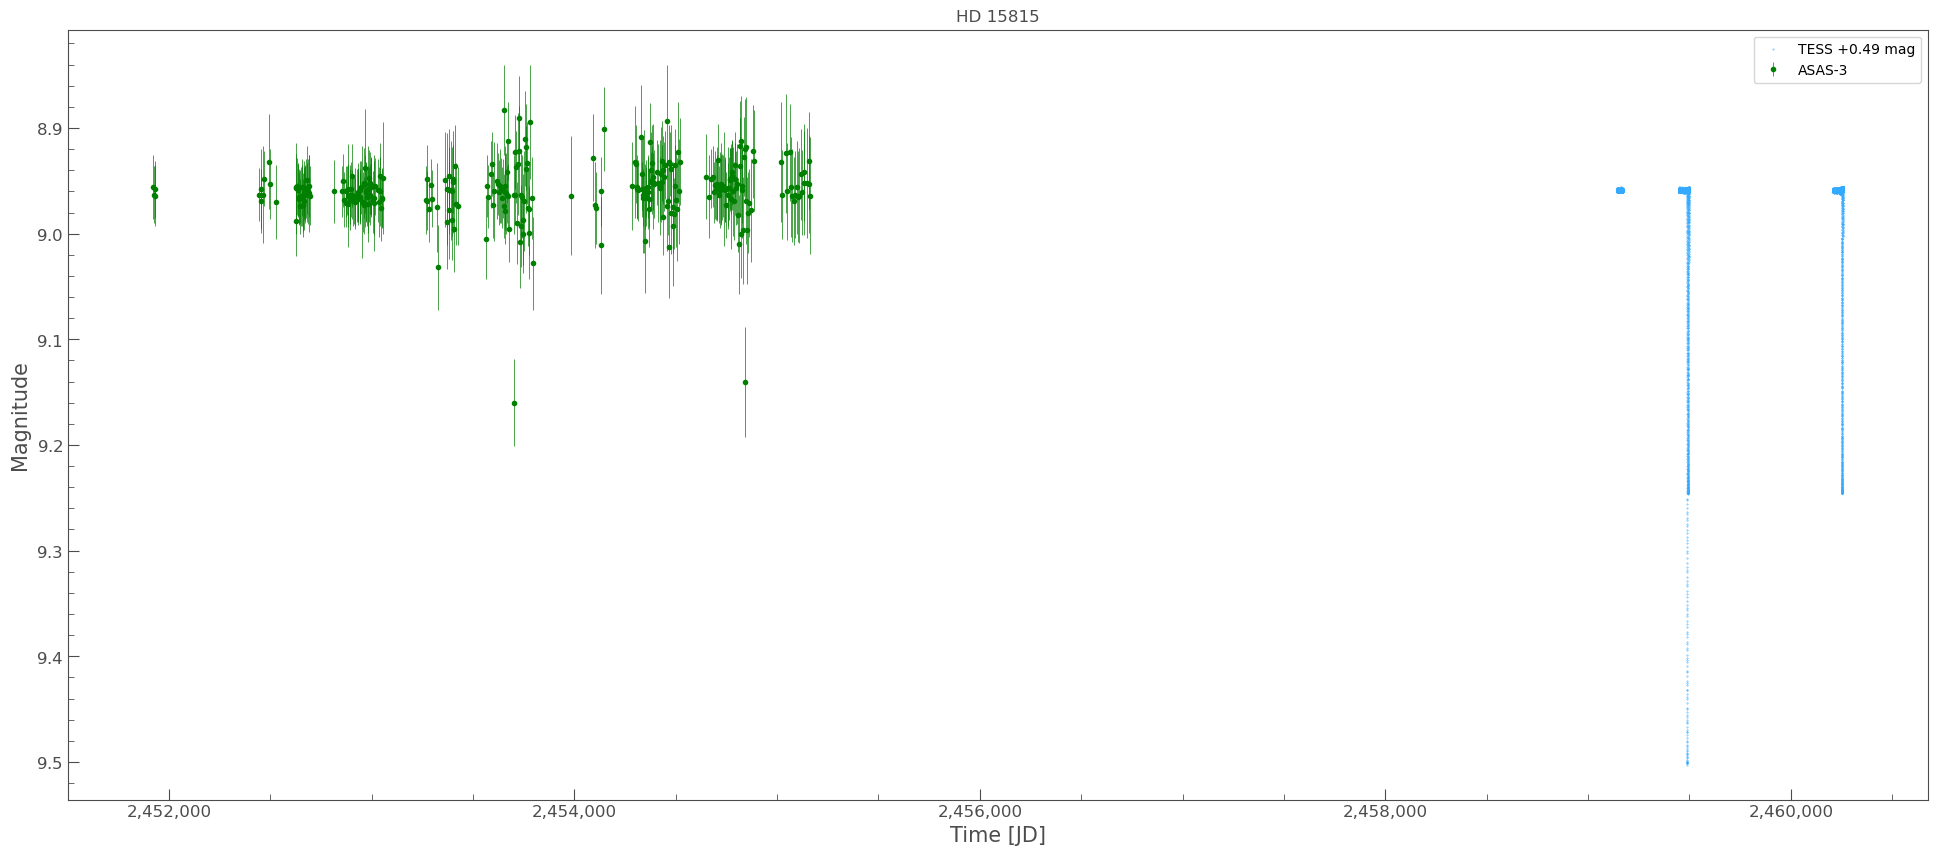

In [125]:
# reload(lkem)
# Not needed
plot_options = lkem.get_default_plot_multi_bands_options_copy()
# plot_options[0][1]["zorder"] = 4

ax = lkem.plot_multi_bands(lc_combined_dict, figsize=(24, 10), target_name=primary_name, plot_options=plot_options);
# ax.set_title(ax.get_title() + "");

#### Phase Plot



In [ ]:
lkem.get_default_plot_multi_bands_options_copy()

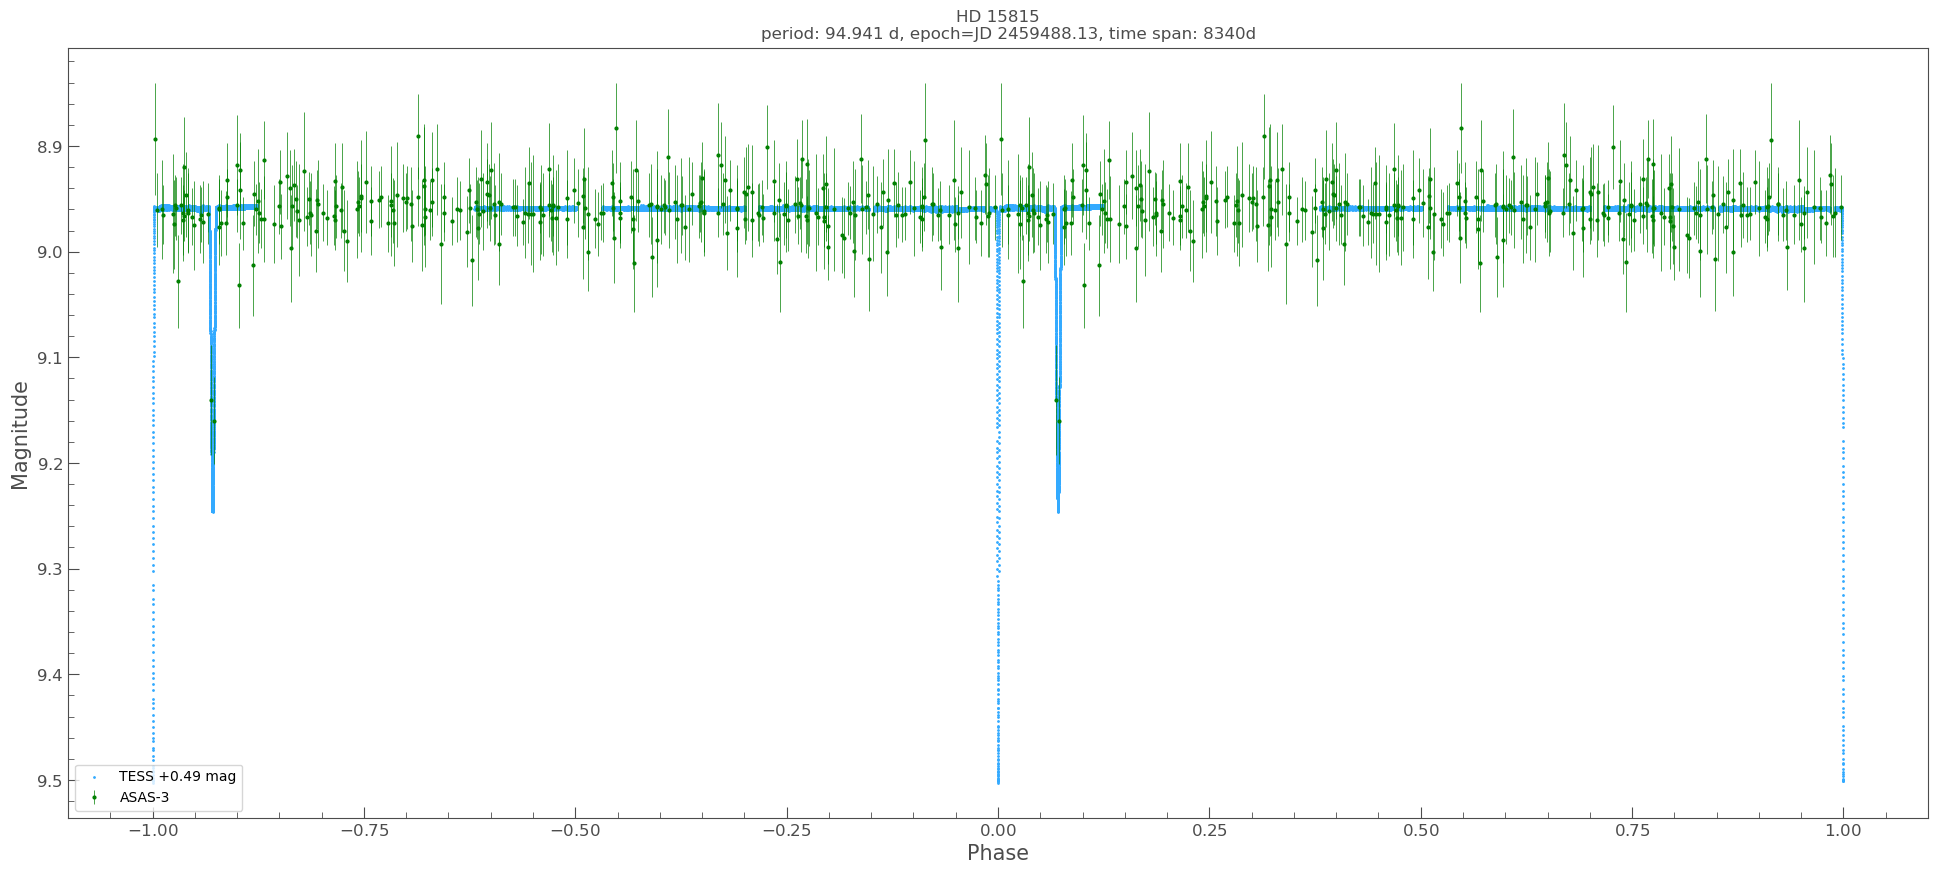

In [89]:
plot_options = lkem.get_default_plot_multi_bands_options_copy()  # use scatter plot , as errrobar is too busy
plot_options[0][1].update(dict(s=1, ))  # make dots larger
plot_options[1][1].update(dict(markersize=4))  # make dots larger

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)  # hide the outliers that are too bright, mostly in ASAS-SN g
ax.set_ylim(*ylim);
# ax.set_title(ax.get_title() + ", outliers truncated");


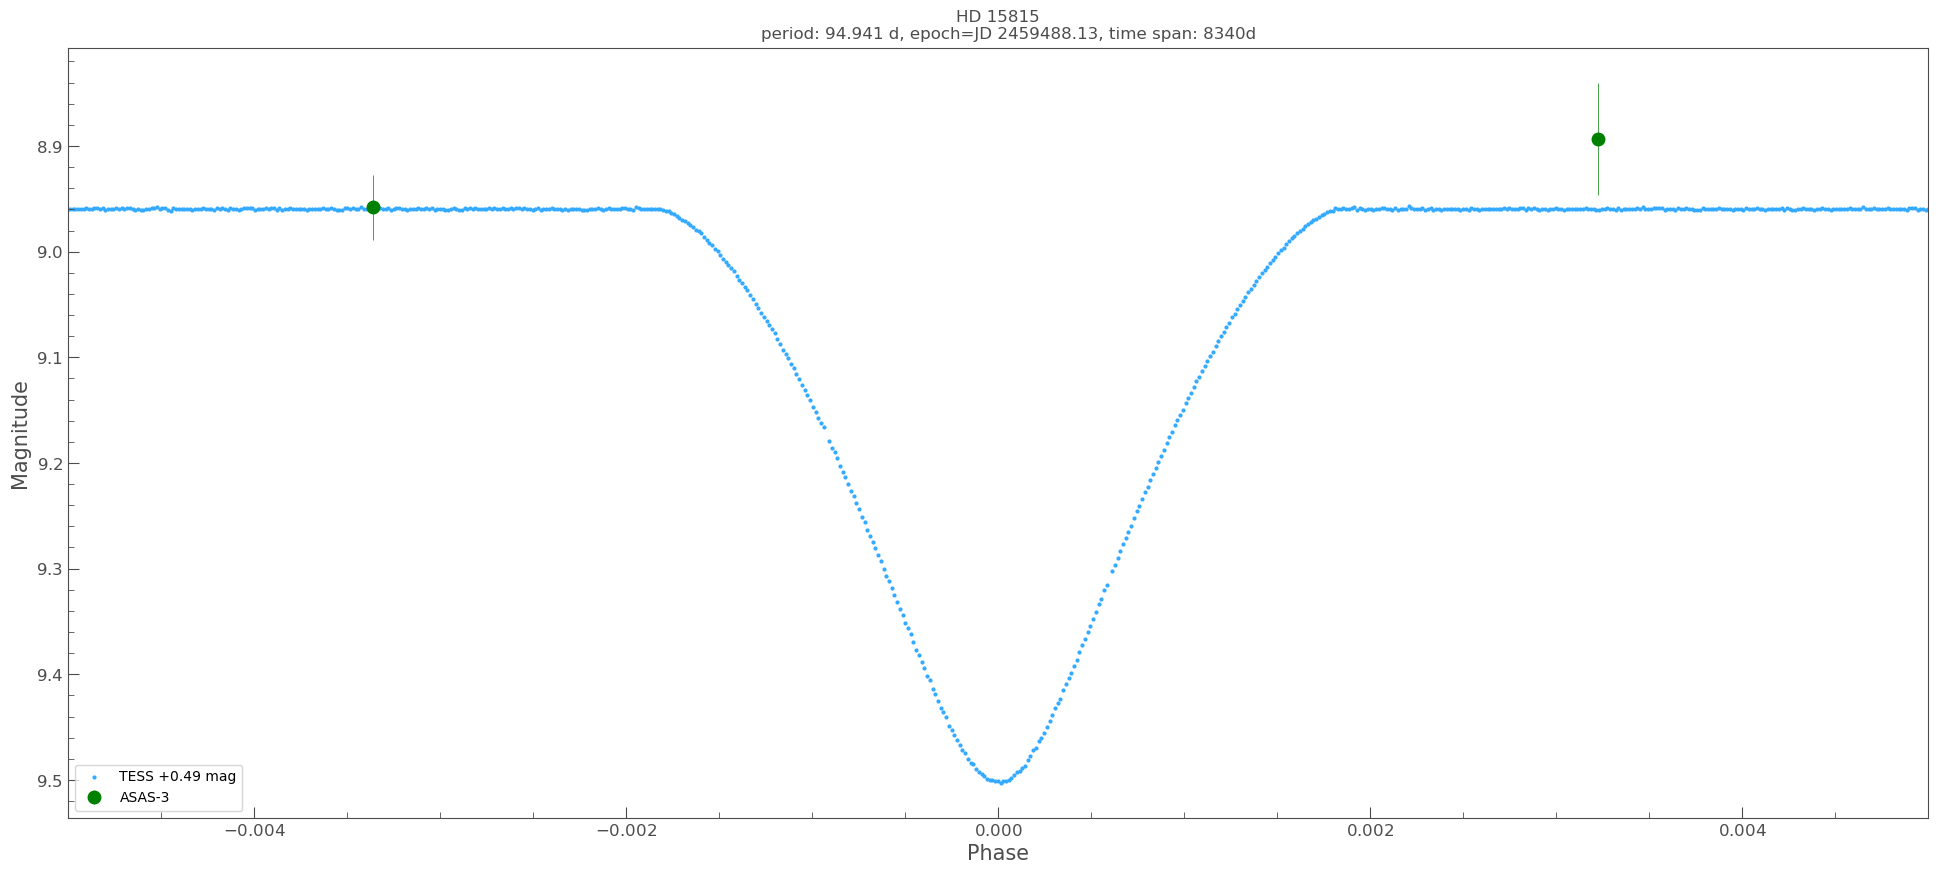

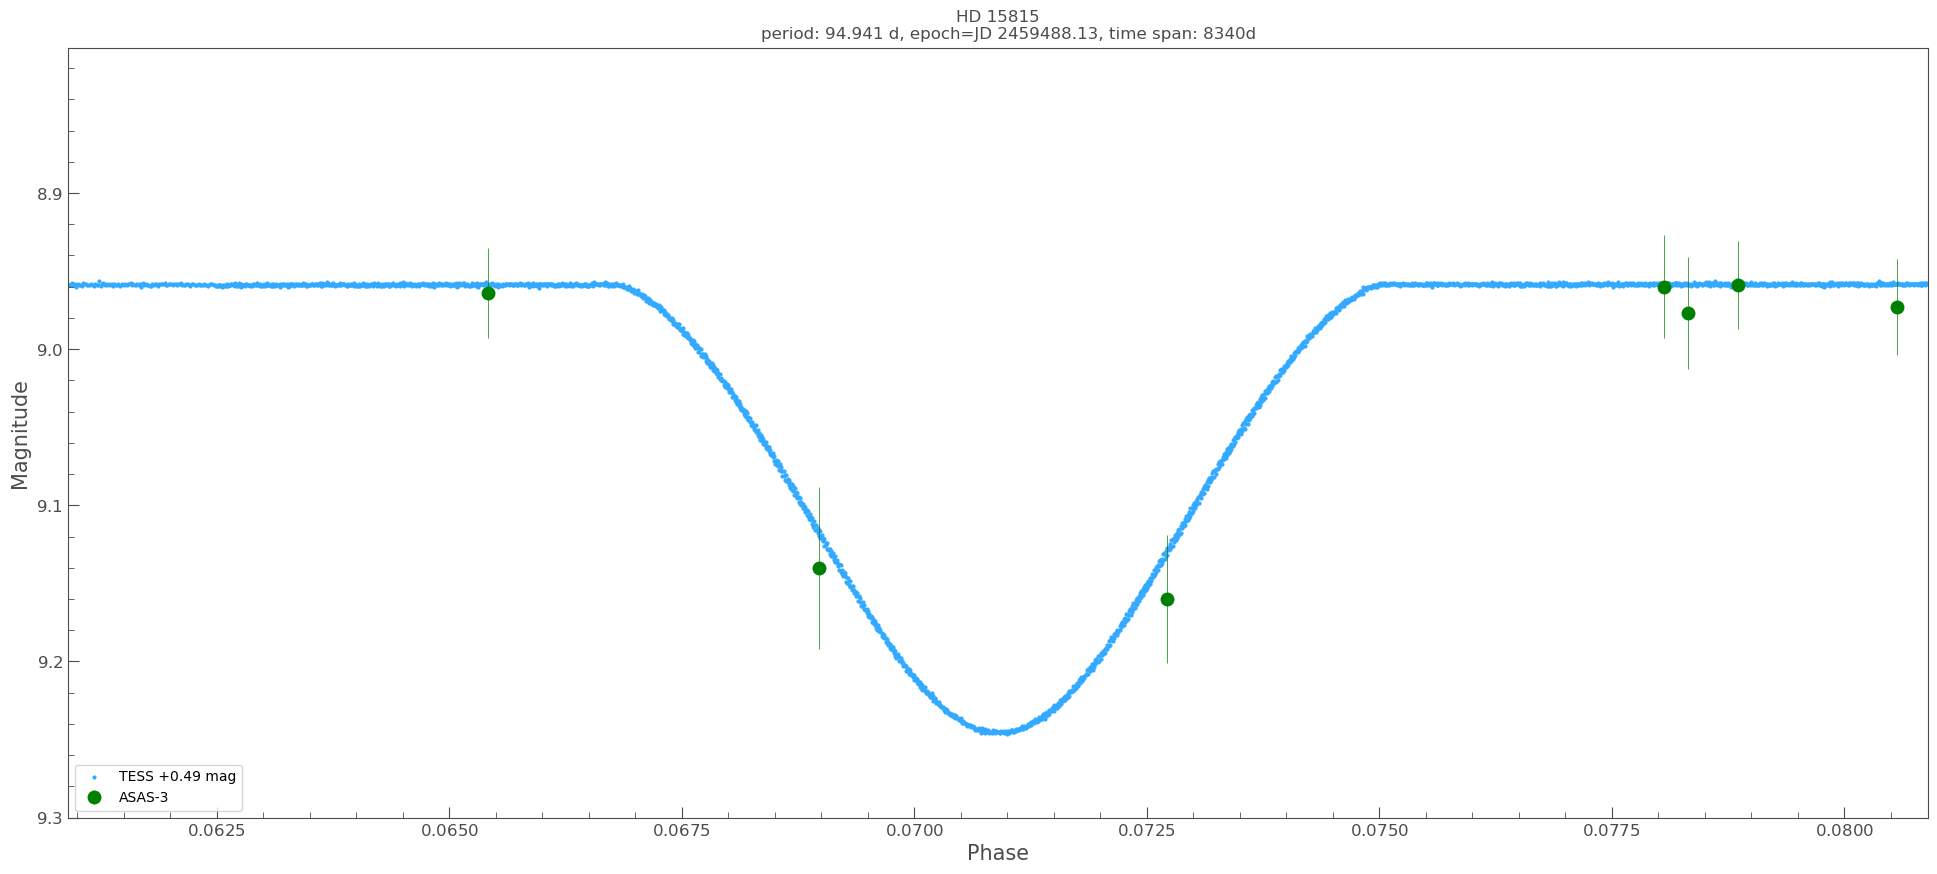

In [102]:
# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1].update(dict(s=4))
plot_options_zoom[1][1].update(dict(marker='o', markersize=9))


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    # duration_hr=duration_hr_min_i_final  ,  # for plotting only
    figsize=(24, 10),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
# ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.005, 0.005);  # to see primary in details
ax.set_ylim(*ylim);
# ax.set_title(ax.get_title() + ", outliers truncated");


# zoom plot Min II
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    # duration_hr=duration_hr_min_ii_final ,  # for plotting only
    # duration_midpoint_phase=epoch_phase_min_ii_final,
    figsize=(24, 10),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
# ax.axvline(epoch_phase_min_ii_final, c="gray", linestyle="dotted");
ax.set_xlim(epoch_phase_min_ii_final - 0.01, epoch_phase_min_ii_final + 0.01);  # to see secondary in details
ax.set_ylim(9.3, None);
# ax.set_title(ax.get_title() + ", outliers truncated");


### JD Plot (TESS)

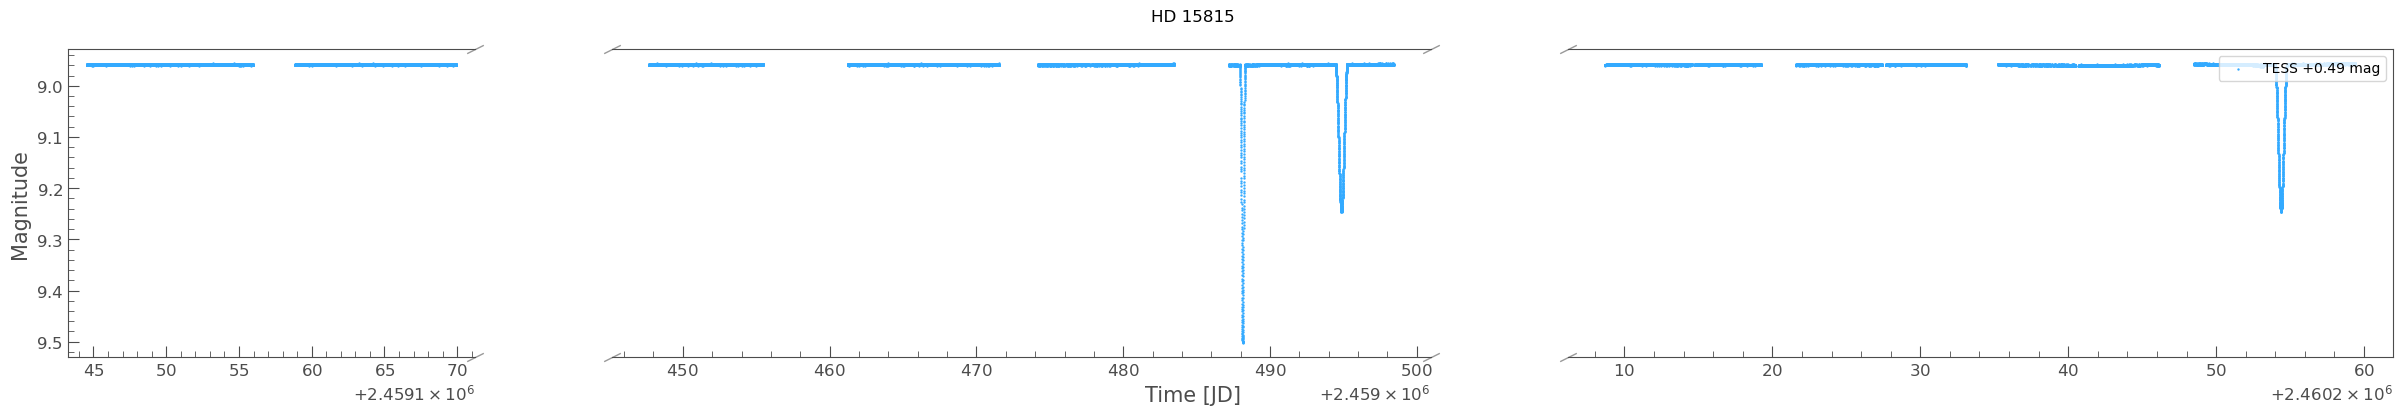

In [139]:
# to shwo the eclipses and the time without eclipses
axs = tplt.plot_skip_data_gap(lc_combined_dict["TESS"], figsize=(30, 4), s=2, c="#3AF", label=lkem.get_label_of_source(lc_combined_dict, "TESS", mag_shift_precision=2));
axs[0].get_figure().suptitle(f"{primary_name}");

## VSX Report Table

In [103]:
def report_to_df(report):
    df = pd.DataFrame()
    df["Field"] = report.keys()
    df["Value"] = report.values()
    return df


def vsx_phase(phase):
    # the phase I used above is from [-0.5, +0.5]
    # convert to the phase [0, 1[ used by VSX
    if phase < -0.5 or phase > 0.5:
        raise ValueError(f"Input phase needs to be in [-0.5, 0.5] range. Actual: {phase}")
    if phase >= 0:
        return phase 
    else: 
        return 1 + phase


In [138]:
import bibs_utils
# reload(bibs_utils)

other_names = f"TIC {tic}"
other_names += ",ASAS J023246+0725.6"  # -- use ASAS-3 data
other_names += ",2MASS J02324589+0725338,TYC 52-00418-1"  # in ExoFOP and SIMBAD
other_names +=",GSC 00052-00418,SAO 110602,BD+06 382"  # other useful IDs from SIMBAD


remarks = (
    f"""Eccentric system. Min II at phase {epoch_phase_min_ii_final}, amplitude {amp_min_ii_flux_mag} TESS, duration {100 * duration_hr_min_ii_final / 24 / period_final:.2f}%."""
    f""" The period is uncertain due to insufficient data. The ~94.9 d value in the main table assumes that the ASAS-3 data have (2) data points around Min II."""
    f""" If the 2 data points are outliers, the possible periods range from 50.635 d to 759.525 d."""
)

# Not neeed for initial submission:
# - Type, period, epoch, eclipse duration from TESS and ASAS=3 data. Amplitude from TESS data.
revision_comment = "Maximum magnitude from ASAS-3 data. Spectral type from 1993yCat.3135....0C. Gaia DR3 position."

BIBS = bibs_utils.BIBS
vsx_report = dict(
    Position=f"{target_coord.ra.value:.5f}, {target_coord.dec.value:.5f}",  # VSX coordinate precision
    Primary_Name=primary_name,
    Other_Names=other_names,
    Variable_Type="EA",
    Spectral_Type="F5",  # from HD -- https://vizier.cds.unistra.fr/viz-bin/VizieR-4?-source=III/135&HD=15815
    Spectral_Type_Uncertain=False,
    Maximum_Magnitude=f"{median_flux_vmag}",  # from ASAS-3 data
    Maximum_Magnitude_band="V",
    Minimum_Magnitude=f"{amp_min_i_flux_mag}",
    Minimum_Magnitude_band="TESS",  
    Minimum_Is_Amplitude=True,
    Period=f"{period_final}",  
    Period_Uncertain=True,
    Epoch=f"{epoch_time_hjd_final}",  
    Rise_Duration_Pct=f"{100 * duration_hr_min_i_final / 24 / period_final:.2f}",  # 2 decimal point is enough visually
    Discoverer="Sam Lee, Planet Hunters TESS Collaboration",  # PHT Talk:  https://www.zooniverse.org/projects/nora-dot-eisner/planet-hunters-tess/talk/subjects/94819374, https://www.zooniverse.org/projects/nora-dot-eisner/planet-hunters-tess/talk/search?query=TIC%20337216607
    Remarks=remarks,
    Revision_Comment=revision_comment,
    Reference0_Name=BIBS.TESS_N,
    Reference0_Bib=BIBS.TESS_B,
    Reference1_Name=BIBS.ASAS3_N,
    Reference1_Bib=BIBS.ASAS3_B,
    Reference2_Name="Cannon, A. J.; Pickering, E. C., 1993, Henry Draper Catalogue and Extension (Cannon+ 1918-1924; ADC 1989) ",
    Reference2_Bib="1993yCat.3135....0C",
)


def print_long_fields(report):
    other_names_list = report["Other_Names"].split(",")
    print("Other Names (1 line each):")
    print("\n".join(other_names_list))
    print("")
    print(report["Remarks"])
    print("")
    print(report["Revision_Comment"])

print_long_fields(vsx_report)
with pd.option_context('display.max_colwidth', None):
    display(report_to_df(vsx_report))


print("""
tic337216607_phase_plot_eclipses.png : EA Phase Plot - EA Phase Plot from TESS and ASAS-3 data, shifted to ASAS-3.
tic337216607_phase_plot_eclipses_zoom_min_i.png : EA Phase Plot (Min I Zoom) - EA Phase Plot from TESS and ASAS-3 data, shifted to ASAS-3. Zoomed around Min I.
tic337216607_phase_plot_eclipses_zoom_min_ii.png : EA Phase Plot (Min II Zoom) - EA Phase Plot from TESS and ASAS-3 data, shifted to ASAS-3. Zoomed around Min II.
tic337216607_jd_plot_tess.png : TESS Lightcurve - TESS Lightcurve
""")


Other Names (1 line each):
TIC 337216607
ASAS J023246+0725.6
2MASS J02324589+0725338
TYC 52-00418-1
GSC 00052-00418
SAO 110602
BD+06 382

Eccentric system. Min II at phase 0.0709, amplitude 0.29 TESS, duration 0.81%. The period is uncertain due to insufficient data. The ~94.9 d value in the main table assumes that the ASAS-3 data have (2) data points around Min II. If the 2 data points are outliers, the possible periods range from 50.635 d to 759.525 d.

Maximum magnitude from ASAS-3 data. Spectral type from 1993yCat.3135....0C. Gaia DR3 position.


,Field,Value
0,Position,"38.19117, 7.42608"
1,Primary_Name,HD 15815
2,Other_Names,"TIC 337216607,ASAS J023246+0725.6,2MASS J02324589+0725338,TYC 52-00418-1,GSC 00052-00418,SAO 110602,BD+06 382"
3,Variable_Type,EA
4,Spectral_Type,F5
5,Spectral_Type_Uncertain,False
6,Maximum_Magnitude,8.96
7,Maximum_Magnitude_band,V
8,Minimum_Magnitude,0.54
9,Minimum_Magnitude_band,TESS



tic337216607_phase_plot_eclipses.png : EA Phase Plot - EA Phase Plot from TESS and ASAS-3 data, shifted to ASAS-3.
tic337216607_phase_plot_eclipses_zoom_min_i.png : EA Phase Plot (Min I Zoom) - EA Phase Plot from TESS and ASAS-3 data, shifted to ASAS-3. Zoomed around Min I.
tic337216607_phase_plot_eclipses_zoom_min_ii.png : EA Phase Plot (Min II Zoom) - EA Phase Plot from TESS and ASAS-3 data, shifted to ASAS-3. Zoomed around Min II.
tic337216607_jd_plot_tess.png : TESS Lightcurve - TESS Lightcurve

